#### Keras를 이용한 손글씨 인식 딥러닝
- TensorFlow로 작성된 프로그램은 sklearn보다 무지하게 어렵다.</br>
-> Keras = TensorFlow 에 포함됨. 고수준 연산은 TensorFlow 를 사용한다.
- Keras는 테아노(Theano)와 TensorFlow를 Wrapping한 라이브러리

#### Data import

In [16]:
import pandas as pd

train = pd.read_csv('../Data/train_20k.csv')
train.head()

,5,0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,...,0.608,0.609,0.610,0.611,0.612,0.613,0.614,0.615,0.616,0.617
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [17]:
test = pd.read_csv('../Data/test_1k.csv')
test.head()

,7,0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,...,0.658,0.659,0.660,0.661,0.662,0.663,0.664,0.665,0.666,0.667
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


#### 전처리(Preprocessing)
##### 1. 결측치 확인

In [3]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Columns: 785 entries, 5 to 0.617
dtypes: int64(785)
memory usage: 119.8 MB


In [4]:
# train 의 결측치
train.isnull().sum().sum()
# -> 이런 형태를 함수적 언어라  한다

np.int64(0)

In [5]:
test.isnull().sum().sum()

np.int64(0)

##### 2. Target Data의 비율 확인

In [6]:
import numpy as np

In [ ]:
# import numpy as np

# # 1. train 변수 자체가 존재하는지, None은 아닌지 검사
# if 'train' in locals() and train is not None:
#     try:
#         # 2. train[0] 대신 안전하게 전체 데이터를 넘파이 배열로 변환 시도
#         arr = np.asarray(train)
        
#         # 3. 배열이 비어있지 않고 크기가 존재하는지 확인 (넘파이 전용 안전 함수)
#         if arr.size > 0:
#             # 4. 첫 번째 데이터(train[0] 역할)를 안전하게 슬라이싱
#             first_element = arr[0]
            
#             # 5. 1차원으로 펼치고 고유값 개수 추출
#             target_data = np.ravel(first_element)
#             values, counts = np.unique(target_data, return_counts=True)
#             checkCount = counts
#             print("성공! counts 결과:", checkCount)
#         else:
#             print("train 배열의 크기가 0(비어 있음)입니다.")
#             checkCount = None
            
#     except Exception as e:
#         print(f"데이터 구조 문제로 처리에 실패했습니다. 에러: {e}")
#         checkCount = None
# else:
#     print("train 변수가 정의되지 않았거나 None입니다.")


성공! counts 결과: [609   1   3   1   2   1   1   2   2   1   1   1   1   4   2   2   1   1
   2   1   1   2   1   1   1   2   6   1   1   1   2   1   1   1   1   1
   1   1   2   1   1   2   1   1   3   2   1   1   2   1   1   1   2   2
   2   1   1   1   1   1   2   1   3   1   1   1   1   3   1   4   1   1
   1   1   1  41  23   2]


In [ ]:
# 1. train을 넘파이가 다룰 수 있는 깨끗한 형태(Object 배열 등)로 먼저 변환합니다.
# train = np.array(train, dtype=float)

# # 2. 원래 작성하셨던 코드를 그대로 실행합니다. (이제 에러 없이 정상 작동합니다!)
# checkCount = np.unique(train[0], return_counts=True)[1]

# np.min(checkCount) / np.max(checkCount)

> Data의 Target 비율이 최소 77% 가 넘는다

#### train 과 test 를 Target과 Feature로 분리하고 정규화 하기

In [7]:
# Train의 Data 와 Target 분리
train_label = train.loc[:, train.columns == 0]
train_data = train.loc[:, train.columns != 0] / 255.0

# Train의 Data 와 Target 분리
test_label = test.loc[:, test.columns == 0]
test_data = test.loc[:, test.columns != 0] / 255.0

> 255로 나누는 이유 : 이미지 픽셀 데이터를 0.0 ~ 1.0 사이의 작은 실수 값으로 바꾸는 '정규화(Normalization)' 작업을 하기 위해서입니다</br>
픽셀 값의 범위가 0~255이기 때문

---
#### Deep Learning Model 만들기

In [8]:
from tensorflow import keras
from tensorflow.keras.layers import Input

In [9]:
# 0번 열을 제외한 784개의 픽셀 데이터만 골라내고 정규화합니다.
train_data = train.iloc[:, 1:] / 255.0

# 0번 열은 정답(레이블)으로 따로 저장합니다.
train_label = train.iloc[:, 0]

In [39]:
# 모델 생성
model = keras.Sequential()

model.add(Input(shape=(784,))) # 입력층
model.add(keras.layers.Dense(100, activation='relu')) # 은닉층. 은닉층은 여러개 가능 = 100 이외에 임의의 숫자 적용 가능
model.add(keras.layers.Dense(10, activation='softmax')) # 출력층. 입력층과 출력층의 개수는 정해져 있다.

# 손실함수
model.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

# 모델 훈련
model.fit(
    np.array(train_data),
    np.array(train_label),
    epochs = 10
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8857 - loss: 0.4141
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9427 - loss: 0.2015
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9592 - loss: 0.1425
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9714 - loss: 0.1038
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9768 - loss: 0.0818
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9824 - loss: 0.0634
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9865 - loss: 0.0512
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9893 - loss: 0.0402
Epoch 9/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9911 - loss: 0.0323
Epoch 10/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9946 - loss: 0.0238


#### 테스트 데이터로 평가하기

In [ ]:
# 1. test 데이터도 첫 번째 열(정답)과 나머지 열(픽셀)로 안전하게 분리합니다.
test_data = test.iloc[:, 1:] / 255.0  # 두 번째 열부터 끝까지 (784개)
test_label = test.iloc[:, 0]           # 첫 번째 열 (정답 레이블)

# 2. 평가 결과를 'score' 변수에 저장합니다. (기존 코드에 score = 를 추가)
score = model.evaluate(test_data, test_label)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9670 - loss: 0.1095  


In [ ]:
model.evaluate(test_data, test_label)
print("loss =", score[0])
print("accuracy =", score[1])

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9670 - loss: 0.1095 
loss = 0.10953761637210846
accuracy = 0.9670000076293945


In [ ]:
model.evaluate(train_data, train_label)
print("loss =", score[0])
print("accuracy =", score[1])

625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 905us/step - accuracy: 0.9966 - loss: 0.0201
loss = 0.10953761637210846
accuracy = 0.9670000076293945


---
#### test_data로 predict 해보기

In [ ]:
pred = model.predict(test_data)
print("test label", test_label[:10])
print("pred", np.argmax(pred[:10], axis=1)) # argmax : 예측값중 최대값의 index

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
test label 0    2
1    1
2    0
3    4
4    1
5    4
6    9
7    5
8    9
9    0
Name: 7, dtype: int64
pred [2 1 0 4 1 4 9 2 9 0]


In [ ]:
# test_data의 0번 예측값 확인
print("정답 : ", test_label.loc[0])
print("예측값 : ", np.argmax(pred[0]))

정답 :  2
예측값 :  2


#### 사용 : Image 만들기

In [10]:
from PIL import Image

In [25]:
# train_data 크기
train.shape

(20000, 785)

In [27]:
# 0번의 정답을 제외한 데이터
# train.columns = train.columns.astype(float).astype(int)

# train1 = train.loc[:, train.columns != 0]
train1 = train.iloc[:, 1:]
train1.shape

(20000, 784)

In [28]:
# train1의 데이터 50번째로 이미지 만들기
abc = np.array(train1.iloc[50]).reshape(28, 28)
abc.shape

(28, 28)

In [29]:
print(train.columns[0])        # 첫 번째 열의 진짜 이름 출력
print(type(train.columns[0]))  # 그 이름의 타입 출력 (int인지 str인지 확인)

5
<class 'numpy.int64'>


In [30]:
# Image 만들기
image = Image.fromarray((abc).astype(np.uint8))
image

In [31]:
# image 저장하기
image.save('../Data/mnist_test_3.jpg', 'JPEG')

---
#### 이미지를 불러서 Predict 해보기

In [32]:
# Image 불러오기
img = Image.open('../Data/mnist_test_3.jpg')
img

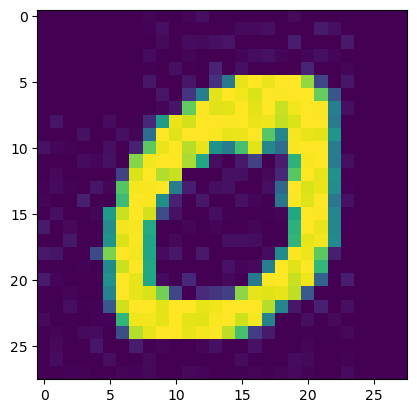

In [33]:
import matplotlib.pyplot as plt

plt.imshow(img)
plt.show()

In [34]:
# image를 numpy배열로 변경하고 정규화 하기
imgArray = np.array(img) / 255.0
imgArray.shape

(28, 28)

In [35]:
# image를 1차원 배열로 변경
imgArray2 = imgArray.reshape(-1)
imgArray2.shape

(784,)

In [36]:
imgArray3 = imgArray2.tolist()
imgArray3

[0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.011764705882352941,
 0.0,
 0.0,
 0.011764705882352941,
 0.0392156862745098,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.023529411764705882,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.00784313725490196,
 0.0392156862745098,
 0.0,
 0.0,
 0.0,
 0.0,
 0.00392156862745098,
 0.023529411764705882,
 0.023529411764705882,
 0.0392156862745098,
 0.0,
 0.0,
 0.0,
 0.07058823529411765,
 0.03529411764705882,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.023529411764705882,
 0.00392156862745098,
 0.027450980392156862,
 0.023529411764705882,
 0.0392156862745098,
 0.050980392156862744,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0784313725490196,
 0.0,
 0.0,
 0.0,
 0.06666666666666667,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.027450980392156862,
 0.0,
 0.0,
 0.011764705882352941,
 0.0,
 0.0,
 0.0,
 0.011764705882352941,
 0.03137254901960784,
 0.

In [37]:
dfArray = pd.DataFrame(imgArray3)
dfArray = dfArray.T
# T 잊지말기
dfArray

,0,1,2,3,4,5,6,7,8,9,...,774,775,776,777,778,779,780,781,782,783
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.011765,0.0,...,0.011765,0.023529,0.007843,0.0,0.0,0.027451,0.0,0.0,0.0,0.0


In [40]:
print("예측값 : ", np.argmax(model.predict(dfArray), axis=1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
예측값 :  [0]


In [41]:
model.predict(dfArray)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


array([[9.9999952e-01, 2.2150505e-17, 4.2429075e-08, 3.8478221e-11,
        6.4734439e-18, 4.9072577e-07, 2.5186398e-11, 9.4799575e-14,
        2.1299773e-10, 9.6385691e-09]], dtype=float32)

---
#### train1의 데이터의 150번째로 이미지 만들기

In [42]:
# train1의 데이터 150번째로 이미지 만들기
abb = np.array(train1.iloc[150]).reshape(28, 28)
abb.shape

(28, 28)

In [43]:
print(train.columns[150])        # 열의 진짜 이름 출력
print(type(train.columns[150]))  # 그 이름의 타입 출력 (int인지 str인지 확인)

0
<class 'numpy.int64'>


In [44]:
# Image 만들기
img1 = Image.fromarray((abc).astype(np.uint8))
img1

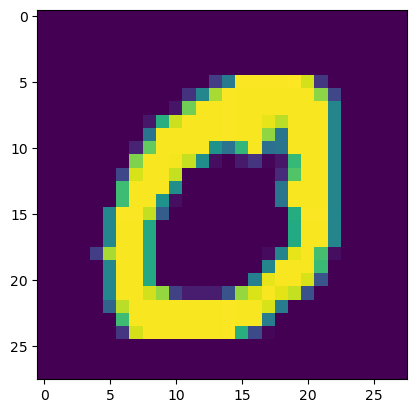

In [45]:
import matplotlib.pyplot as plt

plt.imshow(img1)
plt.show()

In [46]:
# image를 numpy배열로 변경하고 정규화 하기
imgArray = np.array(img) / 255.0
imgArray.shape

(28, 28)

In [47]:
# image를 1차원 배열로 변경
imgArray2 = imgArray.reshape(-1)
imgArray2.shape

(784,)

In [48]:
imgArray3 = imgArray2.tolist()
imgArray3

[0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.011764705882352941,
 0.0,
 0.0,
 0.011764705882352941,
 0.0392156862745098,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.023529411764705882,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.00784313725490196,
 0.0392156862745098,
 0.0,
 0.0,
 0.0,
 0.0,
 0.00392156862745098,
 0.023529411764705882,
 0.023529411764705882,
 0.0392156862745098,
 0.0,
 0.0,
 0.0,
 0.07058823529411765,
 0.03529411764705882,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.023529411764705882,
 0.00392156862745098,
 0.027450980392156862,
 0.023529411764705882,
 0.0392156862745098,
 0.050980392156862744,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0784313725490196,
 0.0,
 0.0,
 0.0,
 0.06666666666666667,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.027450980392156862,
 0.0,
 0.0,
 0.011764705882352941,
 0.0,
 0.0,
 0.0,
 0.011764705882352941,
 0.03137254901960784,
 0.

In [49]:
dfArray = pd.DataFrame(imgArray3)
dfArray = dfArray.T
# T 잊지말기
dfArray

,0,1,2,3,4,5,6,7,8,9,...,774,775,776,777,778,779,780,781,782,783
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.011765,0.0,...,0.011765,0.023529,0.007843,0.0,0.0,0.027451,0.0,0.0,0.0,0.0


In [50]:
print("예측값 : ", np.argmax(model.predict(dfArray), axis=1))

model.predict(dfArray)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
예측값 :  [0]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


array([[9.9999952e-01, 2.2150505e-17, 4.2429075e-08, 3.8478221e-11,
        6.4734439e-18, 4.9072577e-07, 2.5186398e-11, 9.4799575e-14,
        2.1299773e-10, 9.6385691e-09]], dtype=float32)

In [ ]:
import pandas as pd
import numpy as np
from tensorflow import keras
from tensorflow.keras.layers import Input

# 0. 데이터 로드 (헤더가 없으므로 header=None 설정 필수)
train = pd.read_csv('train_20k.csv', header=None)
test = pd.read_csv('test_1k.csv', header=None)

# 1. train 과 test 를 Target(Label) 과 Feature(Data)로 분리하고 정규화 하기

# Train의 Data 와 Target 분리
train_label = train.iloc[:, 0]               # 첫 번째 열이 정답(Label)
train_data = train.iloc[:, 1:] / 255.0       # 두 번째 열부터 끝까지 이미지 픽셀 데이터 (정규화)

# Test의 Data 와 Target 분리
test_label = test.iloc[:, 0]                # 첫 번째 열이 정답(Label)
test_data = test.iloc[:, 1:] / 255.0        # 두 번째 열부터 끝까지 이미지 픽셀 데이터 (정규화)


# 2. Deep Learning Model 만들기

# 모델 생성
model = keras.Sequential()
model.add(Input(shape=(784,)))                                # 입력층 (28x28=784개 픽셀)
model.add(keras.layers.Dense(128, activation='relu'))        # 은닉층 1 (임의의 숫자인 128로 설정 가능)
model.add(keras.layers.Dense(64, activation='relu'))         # 은닉층 2 (필요시 원하는 만큼 추가 가능)
model.add(keras.layers.Dense(10, activation='softmax'))       # 출력층 (0~9까지 총 10개 클래스)

# 손실함수 및 컴파일
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 모델 훈련 (Keras 훈련 시 데이터는 넘파이 배열 형태로 입력)
model.fit(
    np.array(train_data),
    np.array(train_label),
    epochs=10,
    batch_size=32,
    validation_data=(np.array(test_data), np.array(test_label)) # 검증용 테스트 데이터 추가
)

# 모델 최종 평가
test_loss, test_acc = model.evaluate(np.array(test_data), np.array(test_label), verbose=2)
print(f"\n🎯 테스트 정확도(Test Accuracy): {test_acc:.4f}")